
正在處理: TSMC (台積電) (2330.TW) ...


[*********************100%***********************]  1 of 1 completed


開始訓練...
Epoch 0 MSE: 0.8091357350349426
Epoch 20 MSE: 0.05114161595702171
Epoch 40 MSE: 0.04319598153233528
Epoch 60 MSE: 0.03709127753973007
Epoch 80 MSE: 0.005481266416609287


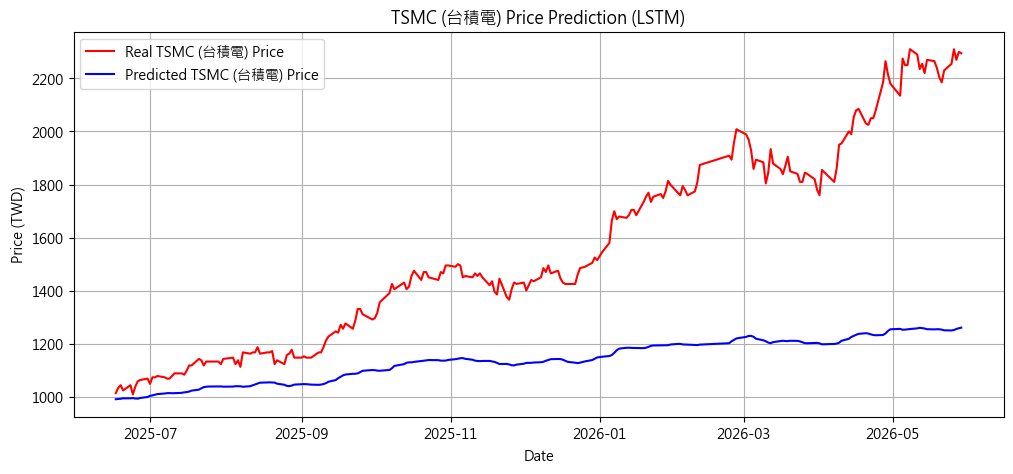


正在處理: MediaTek (聯發科) (2454.TW) ...


[*********************100%***********************]  1 of 1 completed


開始訓練...
Epoch 0 MSE: 0.5944922566413879
Epoch 20 MSE: 0.02488618530333042
Epoch 40 MSE: 0.01823294349014759
Epoch 60 MSE: 0.01770368218421936
Epoch 80 MSE: 0.00480412133038044


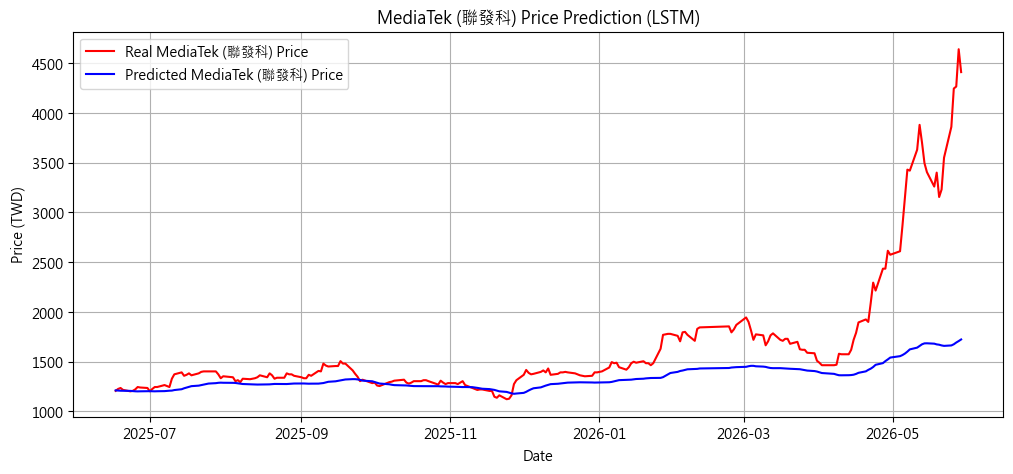


正在處理: Delta (台達電) (2308.TW) ...


[*********************100%***********************]  1 of 1 completed


開始訓練...
Epoch 0 MSE: 0.9166783094406128
Epoch 20 MSE: 0.014774035662412643
Epoch 40 MSE: 0.002736342139542103
Epoch 60 MSE: 0.0025326255708932877
Epoch 80 MSE: 0.0025245011784136295


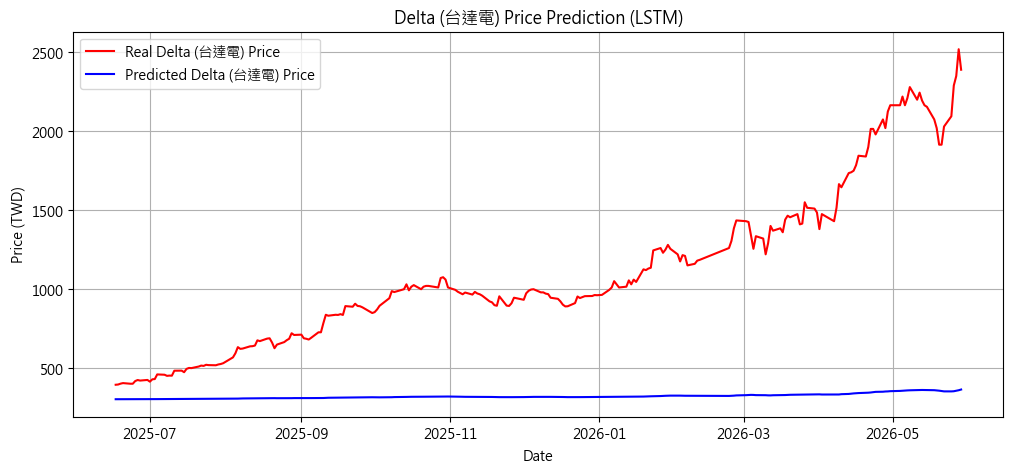

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler
import datetime
import yfinance as yf


plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei'] # 如果你是 Mac 使用者，請改成 'PingFang HK'
plt.rcParams['axes.unicode_minus'] = False 


# 1. 定義 LSTM 模型
class LSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, output_dim):
        super(LSTM, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).requires_grad_()
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).requires_grad_()
        out, (hn, cn) = self.lstm(x, (h0.detach(), c0.detach()))
        out = self.fc(out[:, -1, :]) 
        return out

# 2. 資料處理函數
def load_data(stock, look_back):
    data_raw = stock.values 
    data = []
    
    for index in range(len(data_raw) - look_back): 
        data.append(data_raw[index: index + look_back])
    
    data = np.array(data)
    test_set_size = int(np.round(0.2*data.shape[0]))
    train_set_size = data.shape[0] - (test_set_size)
    
    x_train = data[:train_set_size,:-1,:]
    y_train = data[:train_set_size,-1,:]
    
    x_test = data[train_set_size:,:-1]
    y_test = data[train_set_size:,-1,:]
    
    return [x_train, y_train, x_test, y_test]

# 3. 主執行邏輯
def predict_stock(ticker, stock_name):
    print(f"\n正在處理: {stock_name} ({ticker}) ...")
    
    end_date = datetime.datetime.now()
    start_date = end_date - datetime.timedelta(days=5*365)
    
    try:
        df = yf.download(ticker, start=start_date, end=end_date)
        if df.empty:
            print(f"無法下載 {ticker} 的資料。")
            return
    except Exception as e:
        print(f"下載失敗: {e}")
        return

    # Pandas 2.0 以上建議使用 ffill() 而非 fillna(method='ffill')
    df = df[['Close']].ffill()

    scaler = MinMaxScaler(feature_range=(-1, 1))
    df['Close'] = scaler.fit_transform(df['Close'].values.reshape(-1,1))

    look_back = 60 
    x_train, y_train, x_test, y_test = load_data(df, look_back)

    x_train = torch.from_numpy(x_train).type(torch.Tensor)
    x_test = torch.from_numpy(x_test).type(torch.Tensor)
    y_train = torch.from_numpy(y_train).type(torch.Tensor)
    y_test = torch.from_numpy(y_test).type(torch.Tensor)

    input_dim = 1
    hidden_dim = 32
    num_layers = 2 
    output_dim = 1
    num_epochs = 100

    model = LSTM(input_dim=input_dim, hidden_dim=hidden_dim, output_dim=output_dim, num_layers=num_layers)
    loss_fn = torch.nn.MSELoss()
    optimiser = torch.optim.Adam(model.parameters(), lr=0.01)

    print("開始訓練...")
    for t in range(num_epochs):
        y_train_pred = model(x_train)
        loss = loss_fn(y_train_pred, y_train)
        
        if t % 20 == 0:
            print(f"Epoch {t} MSE: {loss.item()}")

        optimiser.zero_grad()
        loss.backward()
        optimiser.step()

    y_test_pred = model(x_test)

    y_test_real = scaler.inverse_transform(y_test.detach().numpy())
    y_test_pred = scaler.inverse_transform(y_test_pred.detach().numpy())

    plt.figure(figsize=(12, 5))
    test_dates = df.index[len(df) - len(y_test_real):]
    
    plt.plot(test_dates, y_test_real, color='red', label=f'Real {stock_name} Price')
    plt.plot(test_dates, y_test_pred, color='blue', label=f'Predicted {stock_name} Price')
    
    plt.title(f'{stock_name} Price Prediction (LSTM)')
    plt.xlabel('Date')
    plt.ylabel('Price (TWD)')
    plt.legend()
    plt.grid(True)
    plt.show()

# 4. 定義股票清單並執行
stocks = [
    ('2330.TW', 'TSMC (台積電)'),
    ('2454.TW', 'MediaTek (聯發科)'),
    ('2308.TW', 'Delta (台達電)')
]

for ticker, name in stocks:
    predict_stock(ticker, name)
